In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정
plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

# 데이터 불러오기 및 컬럼명 공백/BOM 제거
data = pd.read_csv('../data/인구현황.csv', encoding='utf-8')
data.columns = [col.replace('\ufeff', '').strip() for col in data.columns]

# '전국' 행 제외
data = data.loc[data['행정기관'] != '전국'].copy()

# '남녀 비율' 컬럼 생성 (없는 경우 대비)
if '남녀 비율' not in data.columns:
    data['남녀 비율'] = (data['남자 인구수'] / data['여자 인구수']).round(2)

1. 지역별 총인구수 Top5


,행정기관,총인구수
9,경기도,13694685
1,서울특별시,9331828
2,부산광역시,3266598
16,경상남도,3228380
4,인천광역시,3021010


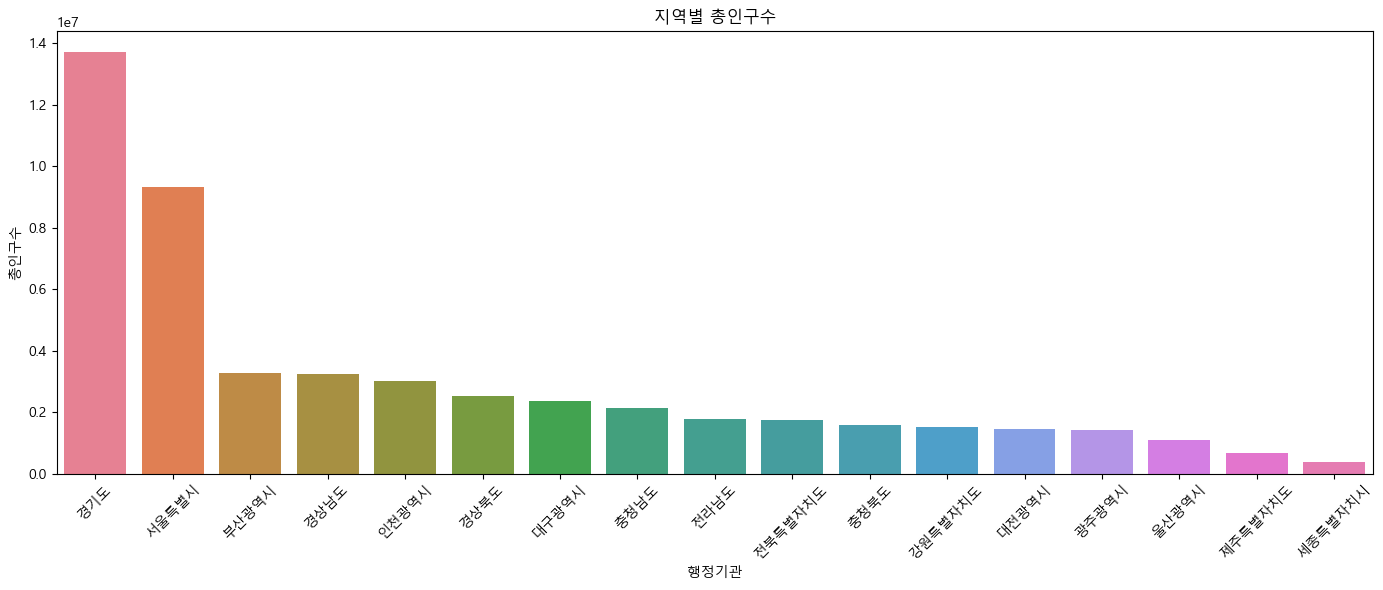

In [6]:

# 1. 지역별 총인구수 Top5 및 Plot
top5_pop = data.loc[:, ['행정기관', '총인구수']].sort_values(by='총인구수', ascending=False).head(5)
print("1. 지역별 총인구수 Top5")
display(top5_pop)

fig, ax1 = plt.subplots(nrows=1, ncols=1)
fig.set_size_inches(14, 6)
sns.barplot(data=data.sort_values(by='총인구수', ascending=False), x='행정기관', y='총인구수', ax=ax1, hue='행정기관')
ax1.set_title("지역별 총인구수")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


2. 세대당 인구수 높은 지역 Top5


,행정기관,세대당 인구
8,세종특별자치시,2.39
9,경기도,2.26
7,울산광역시,2.22
4,인천광역시,2.20
3,대구광역시,2.14


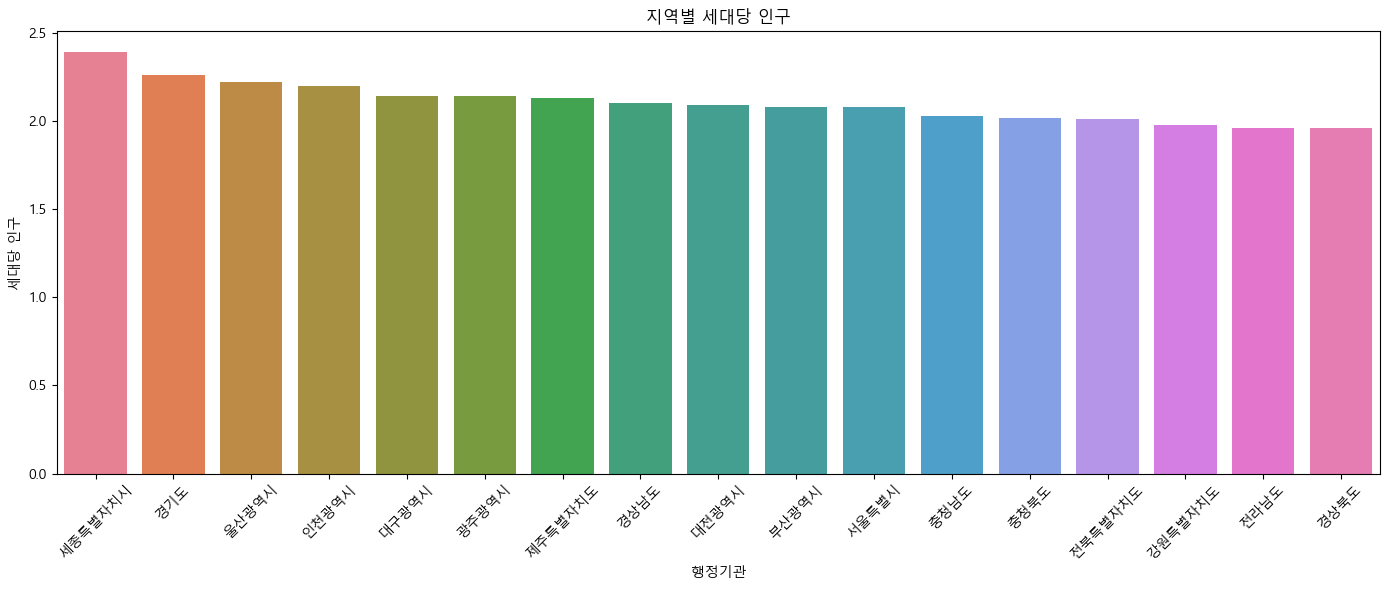

In [7]:

# 2. 세대당 인구수 높은 지역 Top5 및 Plot
top5_hh = data.loc[:, ['행정기관', '세대당 인구']].sort_values(by='세대당 인구', ascending=False).head(5)
print("2. 세대당 인구수 높은 지역 Top5")
display(top5_hh)

fig, ax2 = plt.subplots(nrows=1, ncols=1)
fig.set_size_inches(14, 6)
sns.barplot(data=data.sort_values(by='세대당 인구', ascending=False), x='행정기관', y='세대당 인구', ax=ax2, hue='행정기관')
ax2.set_title("지역별 세대당 인구")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


3. 남녀 비율 분석


,행정기관,남녀 비율
0,울산광역시,1.06
1,충청남도,1.05
2,충청북도,1.04
3,경상남도,1.02
4,경상북도,1.02
5,전라남도,1.02
6,경기도,1.01
7,강원특별자치도,1.01
8,제주특별자치도,1.00
9,인천광역시,1.00


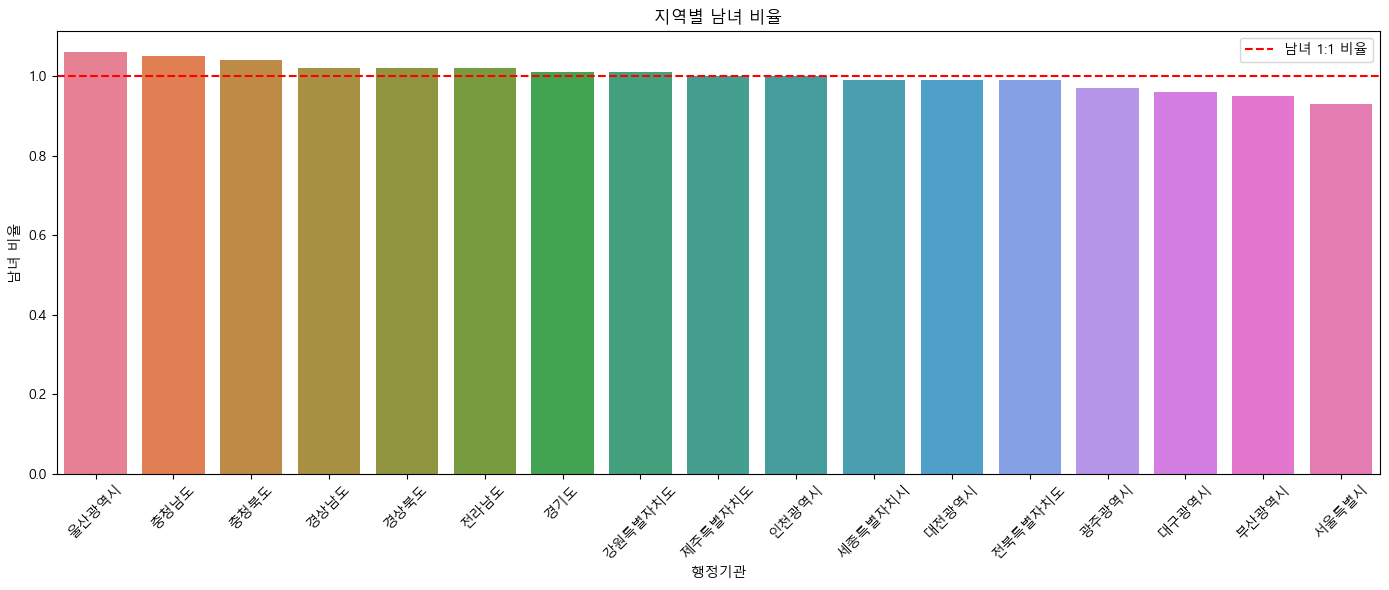

In [9]:
# 3. 남녀 비율 분석 및 Plot

# 컬럼명 공백 제거 (KeyError 방지)
df.columns = df.columns.str.strip()

# '남녀 비율' 컬럼이 없거나 이름이 다르면 직접 계산하여 생성
if '남녀 비율' not in df.columns:
    df['남녀 비율'] = (df['남자 인구수'] / df['여자 인구수']).round(2)

# 데이터 정렬
df_gender = df[['행정기관', '남녀 비율']].sort_values(by='남녀 비율', ascending=False).reset_index(drop=True)

print("3. 남녀 비율 분석")
display(df_gender)

# Plot 그려주기
fig, ax = plt.subplots(figsize=(14, 6))
sns.barplot(data=df_gender, x='행정기관', y='남녀 비율', ax=ax, hue='행정기관')
ax.axhline(y=1.0, color='r', linestyle='--', label='남녀 1:1 비율')
ax.set_title("지역별 남녀 비율")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [10]:

# 4. 남초과 / 여초과 분석 (map 사용)
def get_gender_label(val):
    if val > 1.0: return '남초'
    elif val < 1.0: return '여초'
    else: return '동일'

data['남초여초'] = data['남녀 비율'].map(get_gender_label)
print("4. 남초과 / 여초과 분석")
display(data.loc[:, ['행정기관', '남녀 비율', '남초여초']])


4. 남초과 / 여초과 분석


,행정기관,남녀 비율,남초여초
1,서울특별시,0.93,여초
2,부산광역시,0.95,여초
3,대구광역시,0.96,여초
4,인천광역시,1.00,동일
5,광주광역시,0.97,여초
6,대전광역시,0.99,여초
7,울산광역시,1.06,남초
8,세종특별자치시,0.99,여초
9,경기도,1.01,남초
10,강원특별자치도,1.01,남초


In [11]:

# 5. 세대당 인구 평균보다 높은 지역 (loc 조건 검색 사용)
mean_hh_val = data['세대당 인구'].mean()
print(f"전국 평균 세대당 인구수: {mean_hh_val:.2f}")

above_mean_df = data.loc[data['세대당 인구'] > mean_hh_val, ['행정기관', '세대당 인구']]\
                    .sort_values(by='세대당 인구', ascending=False)\
                    .reset_index(drop=True)
print("5. 세대당 인구 평균보다 높은 지역")
display(above_mean_df)


전국 평균 세대당 인구수: 2.11
5. 세대당 인구 평균보다 높은 지역


,행정기관,세대당 인구
0,세종특별자치시,2.39
1,경기도,2.26
2,울산광역시,2.22
3,인천광역시,2.20
4,대구광역시,2.14
5,광주광역시,2.14
6,제주특별자치도,2.13


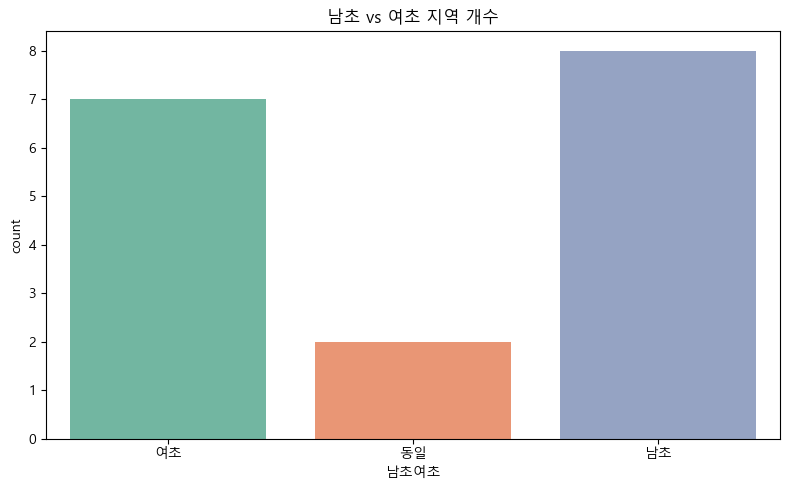

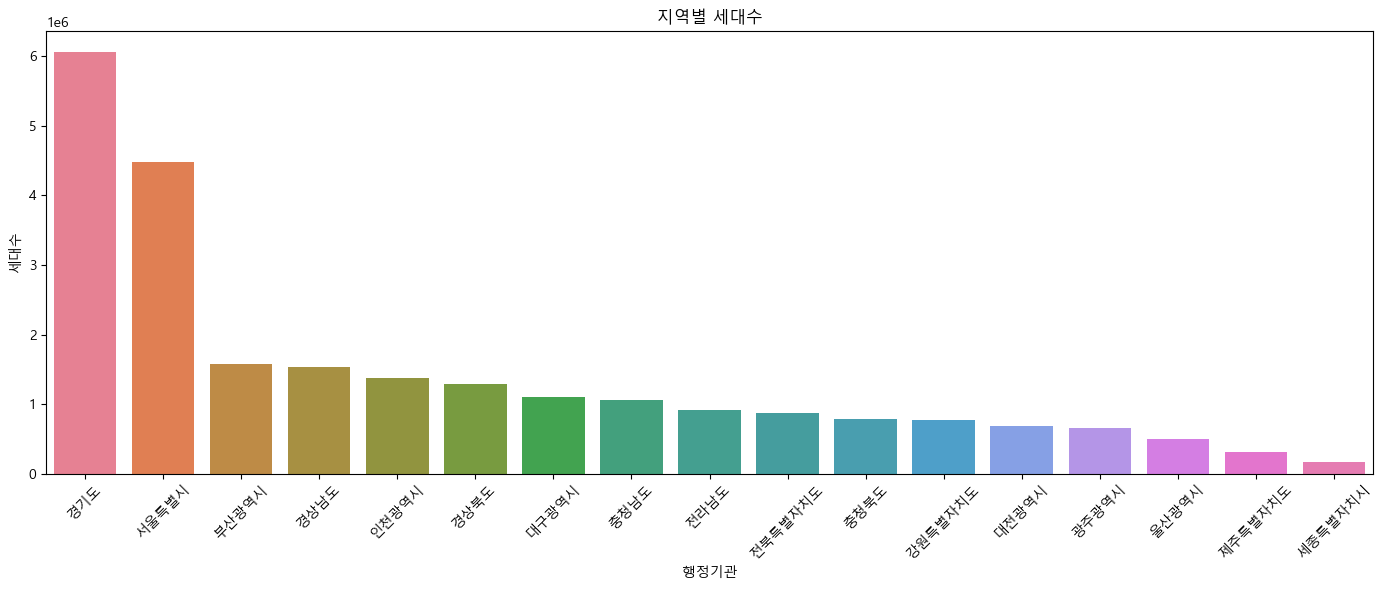

In [12]:

# 5-1. 남초 vs 여초 개수 Plot & 지역별 세대수 Plot
fig, ax4 = plt.subplots(nrows=1, ncols=1)
fig.set_size_inches(8, 5)
sns.countplot(data=data, x='남초여초', ax=ax4, hue='남초여초', palette='Set2')
ax4.set_title("남초 vs 여초 지역 개수")
plt.tight_layout()
plt.show()

fig, ax5 = plt.subplots(nrows=1, ncols=1)
fig.set_size_inches(14, 6)
sns.barplot(data=data.sort_values(by='세대수', ascending=False), x='행정기관', y='세대수', ax=ax5, hue='행정기관')
ax5.set_title("지역별 세대수")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()